# Set up
**Import libraries**

In [1]:
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from knmy import knmy
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
)
from sklearn.preprocessing import RobustScaler

**Load and merge datasets**

In [2]:
df = pd.read_csv("../data/bunny.csv", dtype={'Oryctolagus cuniculus': str})
habitat = pd.read_csv("../data/habitats.csv")

# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

In [3]:
from scipy.spatial.distance import cdist
# Stations lookup
stations_data = {
    'station': [260, 240, 280, 270, 350, 380, 290, 310, 370, 235, 275, 344, 257],
    'lat': [52.101, 52.318, 53.125, 53.202, 51.449, 50.906, 52.933, 51.501, 52.933, 52.928, 52.056, 51.962, 52.506],
    'lon': [5.177, 4.790, 6.585, 5.752, 3.596, 5.762, 4.788, 5.707, 5.444, 4.781, 5.872, 4.447, 4.604],
    'name': ['De Bilt', 'Schiphol', 'Eelde', 'Leeuwarden', 'Vlissingen', 'Maastricht', 
             'Twente', 'Eindhoven', 'Lelystad', 'De Kooy', 'Deelen', 'Rotterdam', 'Wijk aan Zee']
}
stations_df = pd.DataFrame(stations_data)

# Ensure datetime
df["eventDate"] = pd.to_datetime(df["eventDate"])

# Unique locations + nearest station
unique_locs = df[['decimalLatitude', 'decimalLongitude']].drop_duplicates().reset_index(drop=True)

loc_coords = unique_locs[['decimalLatitude', 'decimalLongitude']].values
station_coords = stations_df[['lat', 'lon']].values

distances = cdist(loc_coords, station_coords, metric='euclidean')
nearest_idx = np.argmin(distances, axis=1)

unique_locs['nearest_station'] = stations_df['station'].iloc[nearest_idx].values
unique_locs['station_name'] = stations_df['name'].iloc[nearest_idx].values


# Merge station info back
df = df.merge(unique_locs, 
              on=['decimalLatitude', 'decimalLongitude'], 
              how='left')

# Check if merge worked
print("Columns after station merge:", [col for col in df.columns if 'station' in col.lower() or 'nearest' in col.lower()])

# Download weather
start_date = df["eventDate"].min().strftime("%Y%m%d")
end_date   = df["eventDate"].max().strftime("%Y%m%d")

weather_list = []

for station_id in sorted(unique_locs['nearest_station'].unique()):
    try:
        weather_raw = knmy.get_knmi_data(
            type="daily",
            stations=[int(station_id)],
            start=start_date,
            end=end_date
        )
        
        weather_df = pd.read_csv(StringIO(weather_raw), comment='#', skipinitialspace=True, header=None)
        
        weather_df = weather_df.rename(columns={0: "STN", 1: "YYYYMMDD", 11: "TG", 18: "SQ", 22: "RH"})
        
        weather_df["YYYYMMDD"] = weather_df["YYYYMMDD"].astype(str)
        weather_df["eventDate"] = pd.to_datetime(weather_df["YYYYMMDD"], format="%Y%m%d").dt.normalize()
        
        weather_df["temp_mean"] = pd.to_numeric(weather_df["TG"], errors="coerce") / 10
        weather_df["precip_sum"] = pd.to_numeric(weather_df["RH"], errors="coerce") / 10
        weather_df["sunshine_duration"] = pd.to_numeric(weather_df["SQ"], errors="coerce") / 10
        weather_df["station"] = station_id
        
        weather_list.append(weather_df[['eventDate', 'station', 'temp_mean', 'precip_sum', 'sunshine_duration']])
        
    except Exception as e:
        print(f"⚠️ Error for station {station_id}: {e}")

# Final merge
if weather_list:
    all_weather = pd.concat(weather_list, ignore_index=True)
    
    df = df.merge(
        all_weather, 
        left_on=['eventDate', 'nearest_station'], 
        right_on=['eventDate', 'station'], 
        how='left'
    )
    
    df = df.drop(columns=['station'], errors='ignore')
    
    print(df[['temp_mean', 'precip_sum', 'sunshine_duration']].describe())
    print("\nSample rows:")
    print(df[['eventDate', 'nearest_station', 'station_name', 'temp_mean']].head())
else:
    print("❌ No weather data was downloaded.")

Columns after station merge: ['nearest_station', 'station_name']
          temp_mean    precip_sum  sunshine_duration
count  1.255841e+07  1.255841e+07       1.255824e+07
mean   1.087049e+01  2.255315e+00       5.071856e+00
std    6.225544e+00  4.692560e+00       4.236428e+00
min   -1.380000e+01 -1.000000e-01      -1.000000e-01
25%    6.400000e+00  0.000000e+00       1.200000e+00
50%    1.080000e+01  1.000000e-01       4.400000e+00
75%    1.580000e+01  2.500000e+00       8.200000e+00
max    3.120000e+01  1.316000e+02       1.570000e+01

Sample rows:
   eventDate  nearest_station station_name  temp_mean
0 2010-01-01              380   Maastricht       -2.0
1 2010-01-02              380   Maastricht       -2.1
2 2010-01-03              380   Maastricht       -3.9
3 2010-01-04              380   Maastricht       -5.4
4 2010-01-05              380   Maastricht       -2.3


**Feature enginering**

Because of in the CRISP-DM cycle we went back and forth between data understanding and data preparation and therefore need need the data preparation part feature enigerening before data understanding we are placing it here

In [4]:
df["Oryctolagus cuniculus"] = pd.to_numeric(
    df["Oryctolagus cuniculus"],
    errors="coerce"
)

df["spotted"] = (
    df["Oryctolagus cuniculus"]
    .fillna(0)
    .gt(0)
    .astype(int)
)

df = df.sort_values(["decimalLatitude", "decimalLongitude", "eventDate"])

# Create the future spotted flag
df["is_spotted"] = (
    df.groupby(["decimalLatitude", "decimalLongitude"])["spotted"]
      .transform(lambda x: x[::-1].rolling(window=30, min_periods=1).max()[::-1].shift(-1).fillna(0).astype(int))
)

# to find time patterns
df["day_of_year"] = df["eventDate"].dt.dayofyear

---

# 1. Business Understanding

**Business Objective** 

* To support biodiversity monitoring by predicting whether the European rabbit (Oryctolagus cuniculus) will be observed at a specific location within a 30-day window. The final output is a one-page, non-technical poster identifying key predictors and model performance to inform wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
    * Successful delivery of a one-page poster communicating clear methodology and results.
    * Model performance meets pre-defined thresholds on unseen test data to ensure reliability for conservation action.

**Data Mining Goals**

* Build a supervised binary classification model to predict is_spotted.
* Improve class balance handling to align with ecological monitoring practices.
* Utilize environmental, spatial, and temporal features (land cover, weather, seasonality) to capture non-linear habitat patterns.

**Data Mining Success Criteria**

* Our model should achieve at least:
    * Recall (Primary): Achieve more than 60% to minimize False Negatives (missing rabbit occurrences), which are deemed more harmful than false alarms for biodiversity monitoring.
    * F1-Score (Secondary): Achieve more than 40% to ensure the model maintains a balance and does not sacrifice precision by over-predicting.
    * Evaluation: Metrics must be validated on a separate, unseen hold-out test set to ensure robustness.
    * The model should also maintain stable predictive performance across different regions and seasons.

---


# 2.1 Data understanding
**Data exploration**

In [5]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,...,wetland,main_habitat,nearest_station,station_name,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year
12558769,3.5,52.8,2026-01-14,10.0,1011,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,8.5,4.6,0.0,1,0,14
12558767,3.5,52.9,2026-01-12,100.0,1011,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,5.7,6.1,0.0,0,0,12
12558765,3.5,53.0,2026-01-10,10.0,1011,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,-2.7,2.0,0.0,1,0,10
12558761,3.5,53.1,2026-01-06,99999.0,1011,8.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,-1.5,0.1,1.5,1,0,6
12558760,3.5,53.2,2026-01-05,40.0,1011,-1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,-2.3,2.0,0.2,0,0,5


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558786 entries, 12558769 to 12558755
Data columns (total 23 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Oryctolagus cuniculus      float64       
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  nearest_station            int64         
 16  station_name               str           
 

In [7]:
# Summary statistics
summary = df.describe().T

# Add additional statistics
summary["variance"] = df.var(numeric_only=True)
summary["skewness"] = df.skew(numeric_only=True)
summary["missing"] = df.isnull().sum()

print(summary)

                                count                        mean  \
decimalLatitude            12558786.0                   52.229945   
decimalLongitude           12558786.0                    5.532896   
eventDate                    12558786  2017-12-31 12:10:06.165594   
total_observations         12558783.0                    8.136004   
speciesgroup_observations  12558786.0                    0.221265   
Oryctolagus cuniculus      12558781.0                    0.007165   
agricultural               12558756.0                    9.452277   
built                      12558756.0                    2.404833   
coast                      12558756.0                    1.302932   
forest                     12558756.0                    1.621184   
other                      12558756.0                    1.501486   
sand/heather               12558756.0                    0.188153   
water                      12558756.0                    1.245543   
wetland                    1255875

### Bunny Occurences

Data distribution of target

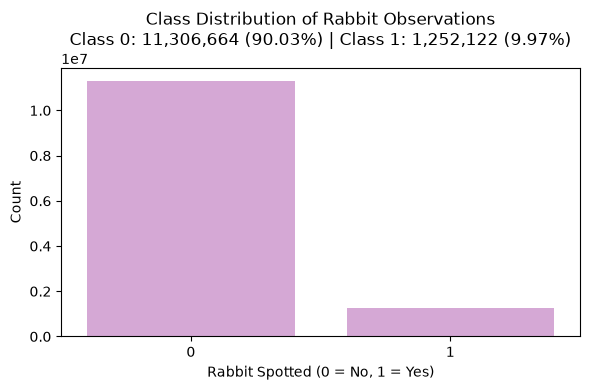

In [8]:
# Counts
counts = df['is_spotted'].value_counts().sort_index()
total = len(df)

count_0 = counts[0]
count_1 = counts[1]

pct_0 = count_0 / total * 100
pct_1 = count_1 / total * 100

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_spotted', color='plum')

plt.title(
    f'Class Distribution of Rabbit Observations\n'
    f'Class 0: {count_0:,} ({pct_0:.2f}%) | '
    f'Class 1: {count_1:,} ({pct_1:.2f}%)'
)

plt.xlabel('Rabbit Spotted (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Habitats

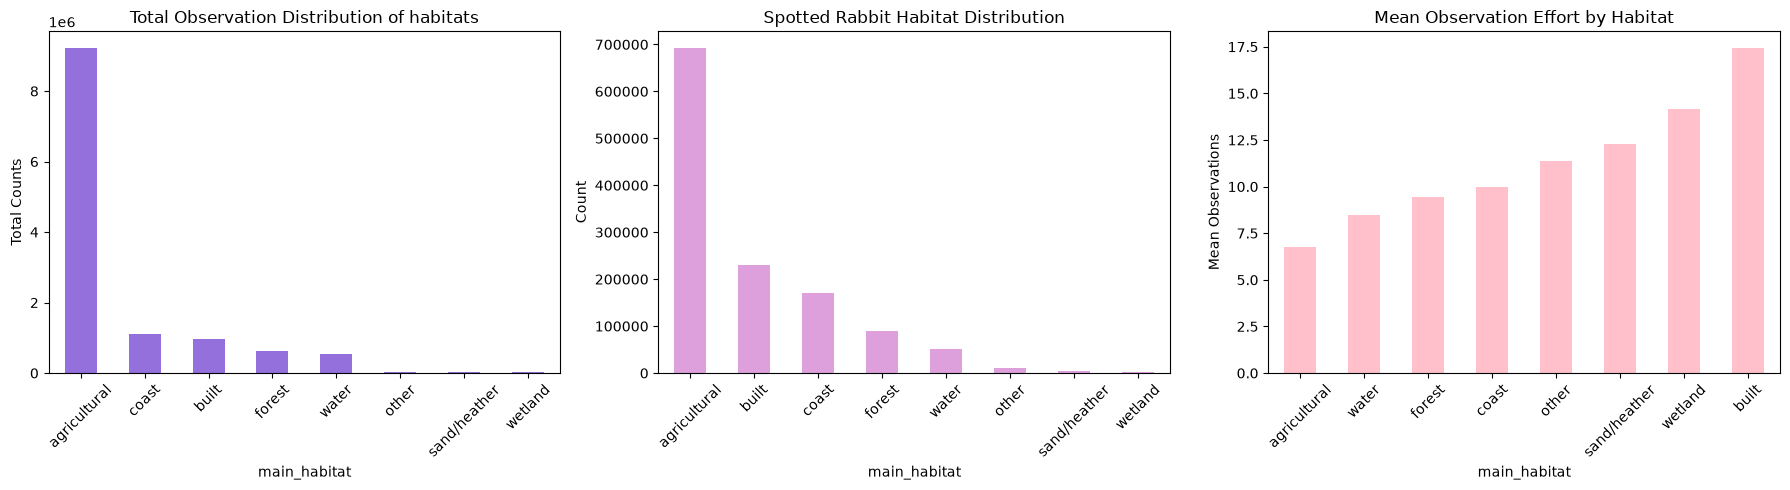

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total Observation Distribution
df["main_habitat"].value_counts().plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Total Observation Distribution of habitats")
axes[0].set_ylabel("Total Counts")
axes[0].tick_params(axis='x', rotation=45)

# 2. Spotted rabbit habitat distribution
df[df["is_spotted"] == 1]["main_habitat"].value_counts().plot(kind="bar", ax=axes[1], color="plum")
axes[1].set_title("Spotted Rabbit Habitat Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# 3. Observation effort by habitat (Mean)
df.groupby("main_habitat")["total_observations"].mean().sort_values().plot(kind="bar", ax=axes[2], color="pink")
axes[2].set_title("Mean Observation Effort by Habitat")
axes[2].set_ylabel("Mean Observations")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
habitat_summary = df['main_habitat'].value_counts().reset_index()
habitat_summary.columns = ['Habitat', 'Count']
habitat_summary['Percentage'] = (habitat_summary['Count'] / habitat_summary['Count'].sum()) * 100

print(habitat_summary)

        Habitat    Count  Percentage
0  agricultural  9233520   73.522569
1         coast  1098672    8.748255
2         built   958416    7.631456
3        forest   631152    5.025593
4         water   543492    4.327594
5         other    40908    0.325733
6  sand/heather    29220    0.232666
7       wetland    23376    0.186133


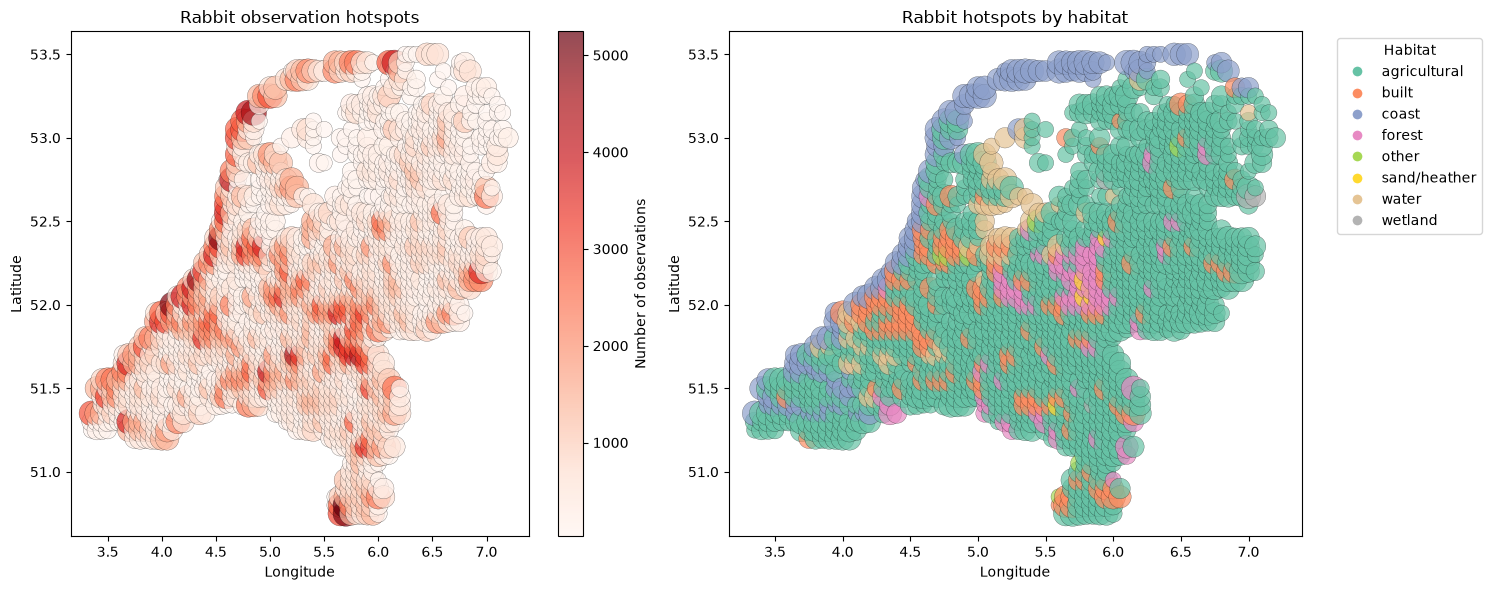

In [11]:
df_spotted = df[df["is_spotted"] == 1]

# 1. Location-only hotspot map
loc_counts_1 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude"]
).size().reset_index(name="count")

loc_counts_1["log_count"] = np.log1p(loc_counts_1["count"])

# 2. Location + habitat map
loc_counts_2 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude", "main_habitat"]
).size().reset_index(name="count")

loc_counts_2["log_count"] = np.log1p(loc_counts_2["count"])

habitats = loc_counts_2["main_habitat"].astype("category")
colors = habitats.cat.codes

# 3. Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(
    loc_counts_1["decimalLongitude"],
    loc_counts_1["decimalLatitude"],
    s=loc_counts_1["log_count"] * 40,
    c=loc_counts_1["count"],
    cmap="Reds",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[0].set_title("Rabbit observation hotspots")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("Number of observations")

sc2 = axes[1].scatter(
    loc_counts_2["decimalLongitude"],
    loc_counts_2["decimalLatitude"],
    s=loc_counts_2["log_count"] * 40,
    c=colors,
    cmap="Set2",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[1].set_title("Rabbit hotspots by habitat")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# habitat legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cm.Set2(i),
               markersize=8,
               label=cat)
    for i, cat in enumerate(habitats.cat.categories)
]

axes[1].legend(handles=handles, title="Habitat",
               bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Weather


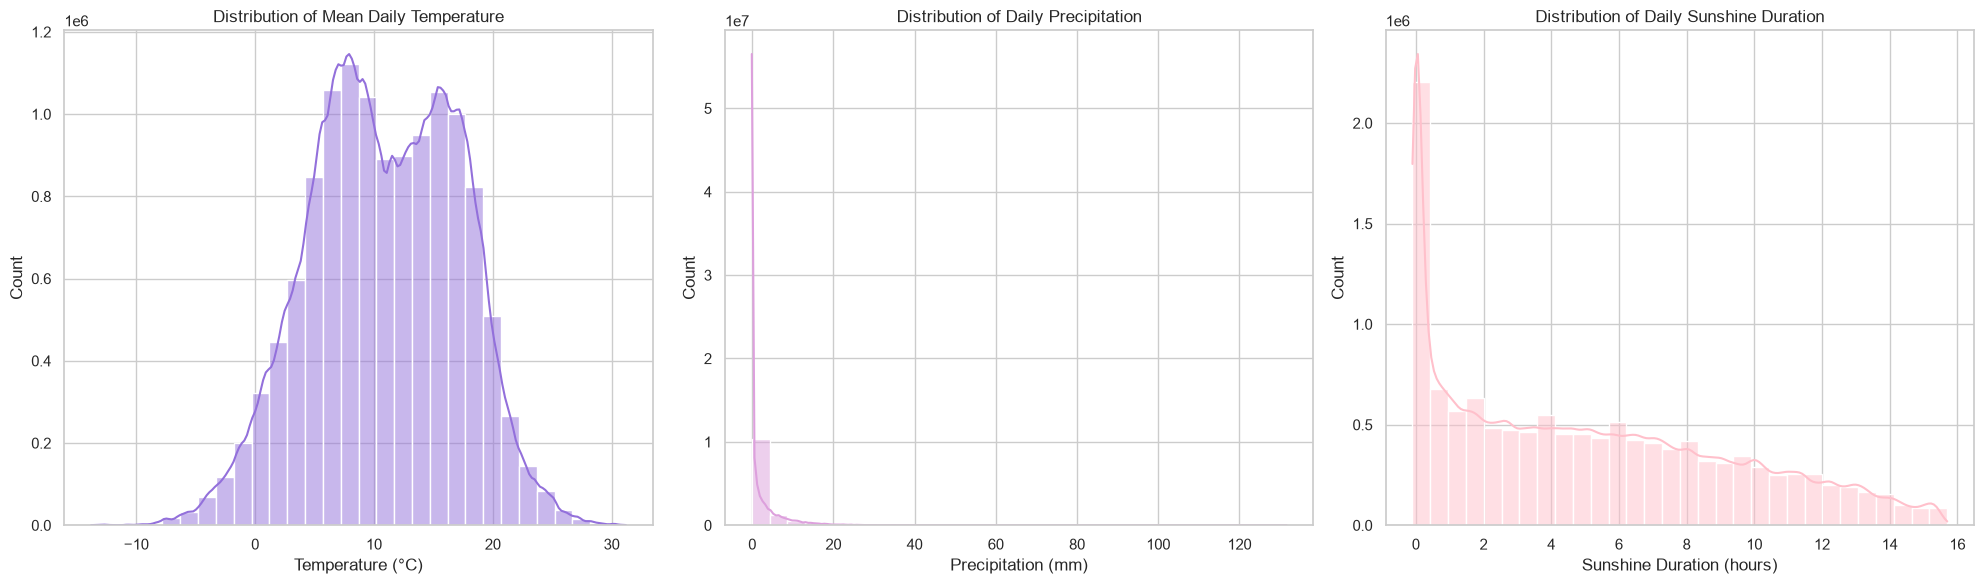

In [12]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram for Temperature
sns.histplot(df['temp_mean'], kde=True, ax=axes[0], color='mediumpurple', bins=30)
axes[0].set_title('Distribution of Mean Daily Temperature')
axes[0].set_xlabel('Temperature (°C)')

# Histogram for Precipitation
sns.histplot(df['precip_sum'], kde=True, ax=axes[1], color='plum', bins=30)
axes[1].set_title('Distribution of Daily Precipitation')
axes[1].set_xlabel('Precipitation (mm)')

# Histogram for Sunshine Duration
sns.histplot(df['sunshine_duration'], kde=True, ax=axes[2], color='pink', bins=30)
axes[2].set_title('Distribution of Daily Sunshine Duration')
axes[2].set_xlabel('Sunshine Duration (hours)')

plt.tight_layout()
plt.show()

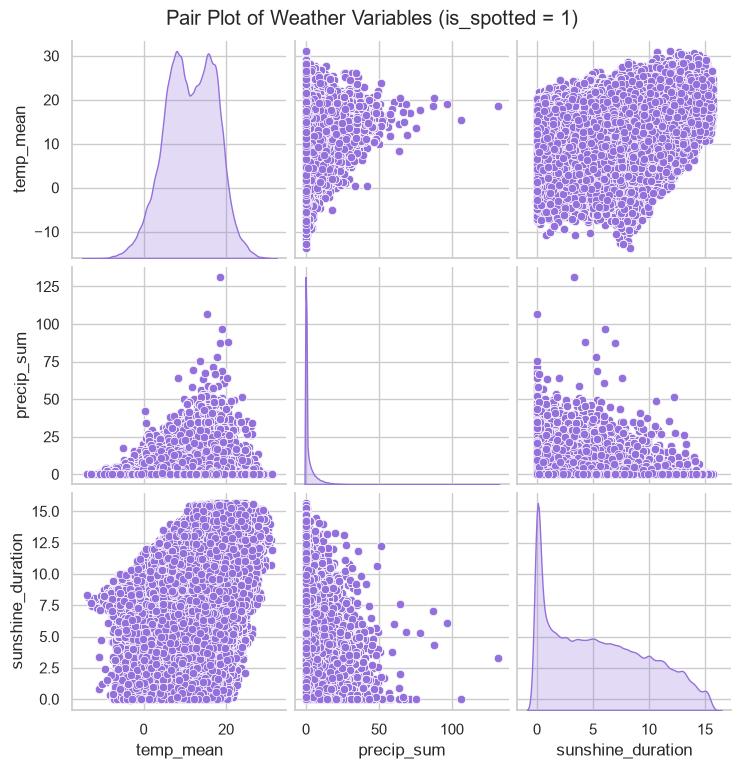

In [13]:
# Filter the DataFrame
df_spotted = df[df['is_spotted'] == 1]
plot_df = df_spotted[['temp_mean', 'precip_sum', 'sunshine_duration']]

# Generate the pairplot using plot_kws and diag_kws to set the color
sns.pairplot(
    plot_df, 
    diag_kind='kde', 
    plot_kws={'color': 'mediumpurple'}, 
    diag_kws={'color': 'mediumpurple'}
)

plt.suptitle('Pair Plot of Weather Variables (is_spotted = 1)', y=1.02)
plt.show()

### Seasonal

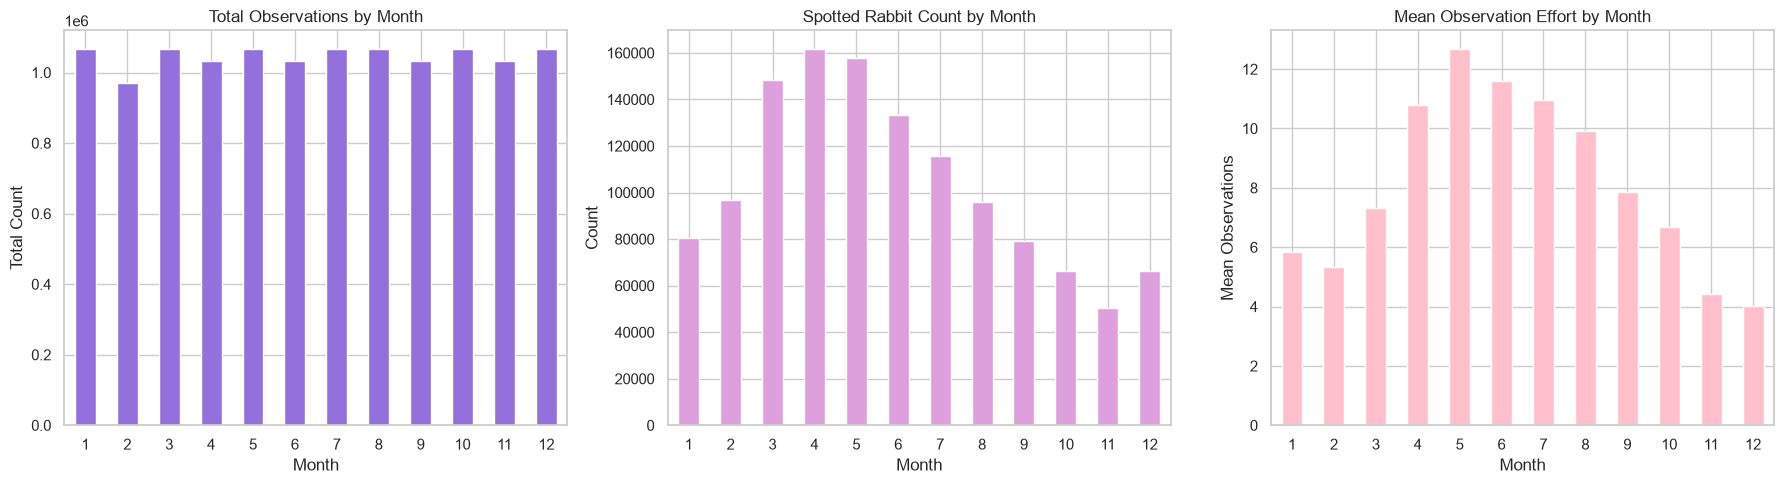

In [14]:
df["month"] = df["eventDate"].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total Observation Distribution by Month
df["month"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Total Observations by Month")
axes[0].set_ylabel("Total Count")
axes[0].set_xlabel("Month")
axes[0].tick_params(axis='x', rotation=0)

# 2. Spotted rabbit distribution by Month
df[df["is_spotted"] == 1]["month"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="plum")
axes[1].set_title("Spotted Rabbit Count by Month")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis='x', rotation=0)

# 3. Mean observation effort by Month
df.groupby("month")["total_observations"].mean().sort_index().plot(kind="bar", ax=axes[2], color="pink")
axes[2].set_title("Mean Observation Effort by Month")
axes[2].set_ylabel("Mean Observations")
axes[2].set_xlabel("Month")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Correlation Heatmaps

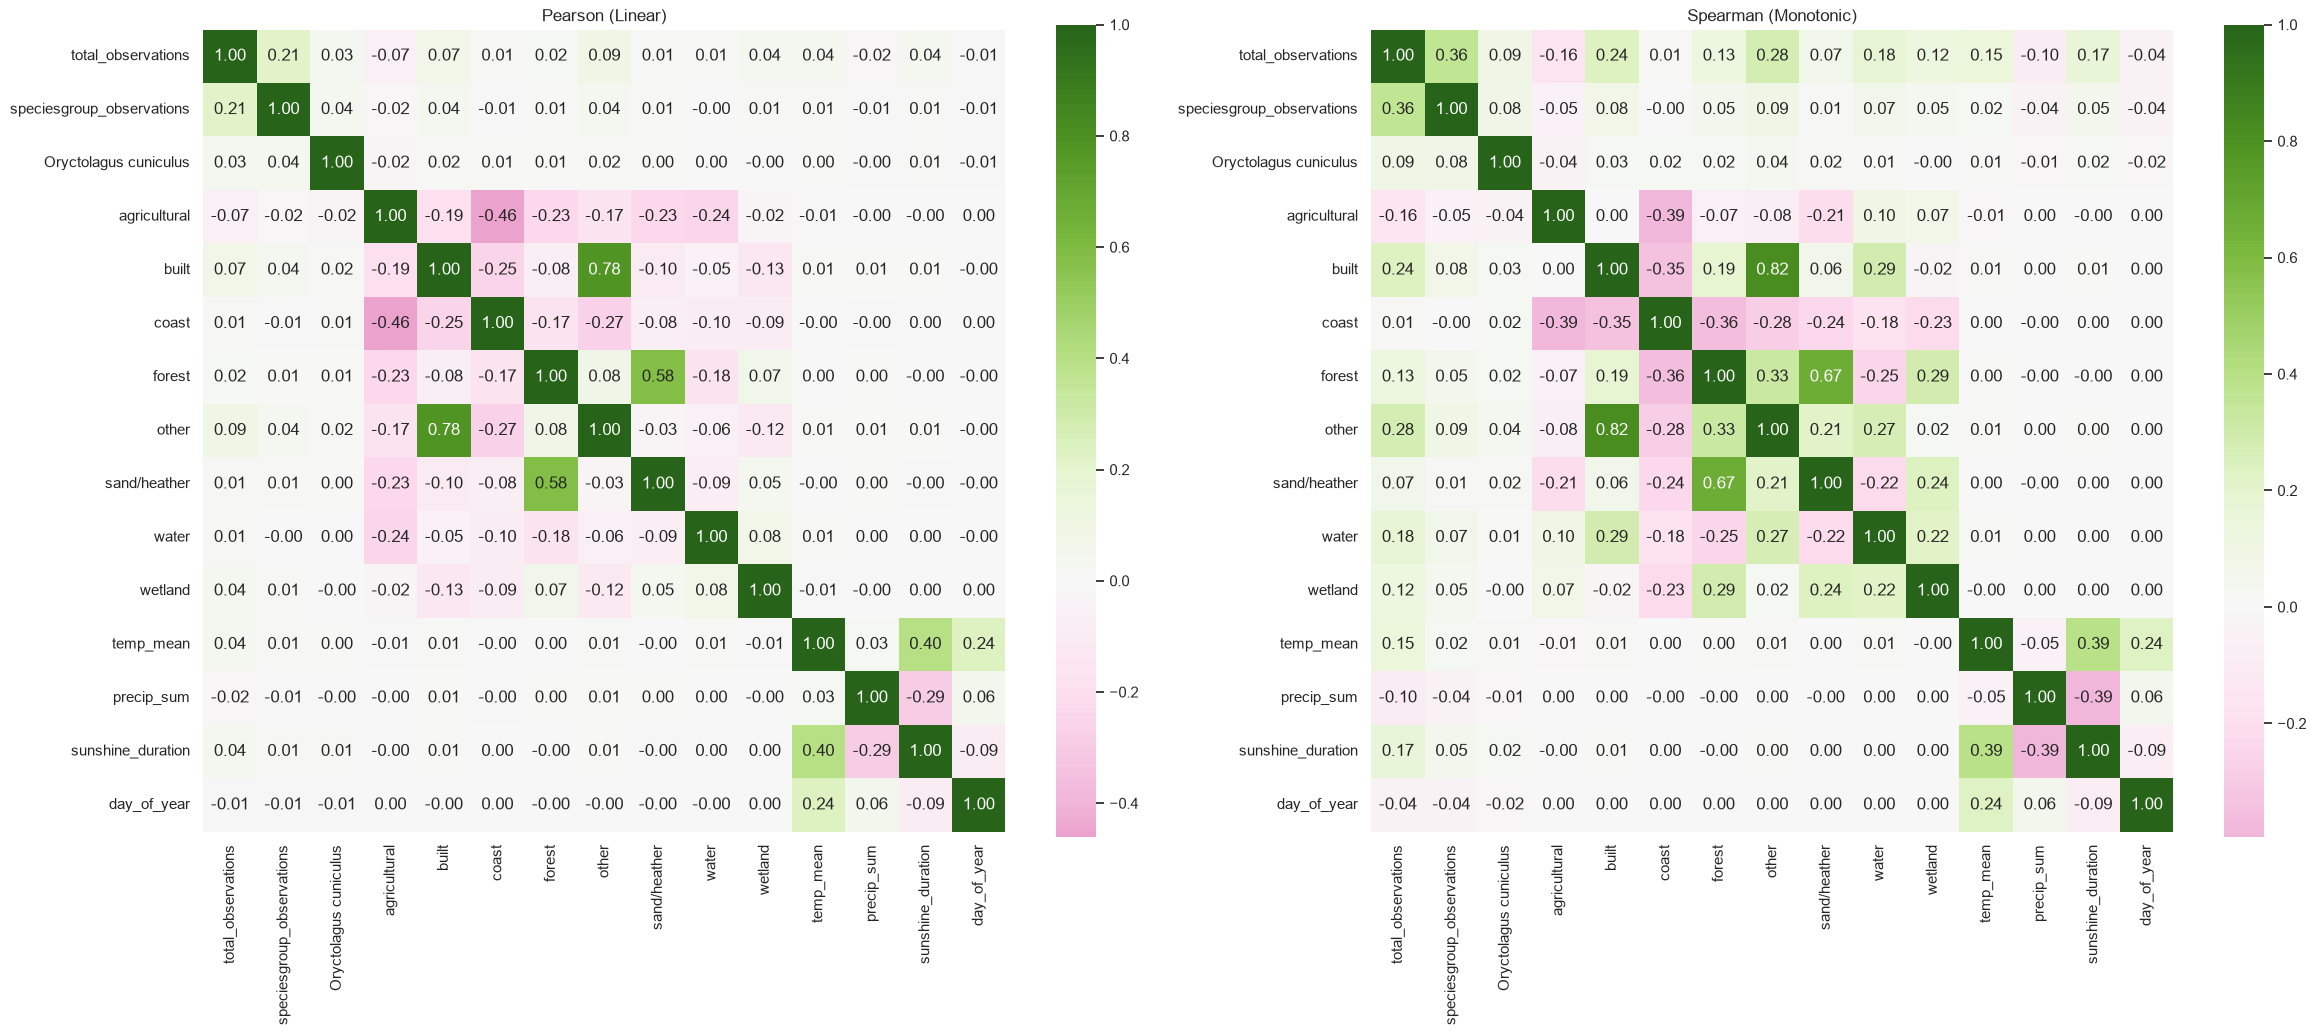

In [15]:
features = [
    "total_observations",
    "speciesgroup_observations",
    "Oryctolagus cuniculus",
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_of_year"
]

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(df[features].corr(), ax=axes[0], annot=True, fmt=".2f", cmap="PiYG", center=0, square=True)
axes[0].set_title("Pearson (Linear)")

sns.heatmap(df[features].corr(method='spearman'), ax=axes[1], annot=True, fmt=".2f", cmap="PiYG", center=0, square=True)
axes[1].set_title("Spearman (Monotonic)")

plt.tight_layout()
plt.show()

**Findings**

Because all values in the is_spotted row are extremely close to zero, it can be concluded that there is no single linear feature that strongly predicts whether something is spotted. This suggests that the relationship between these features and is_spotted is likely non-linear or complex, and cannot be captured through simple correlation analysis.

### Line Charts
Too look for non-linear correlations

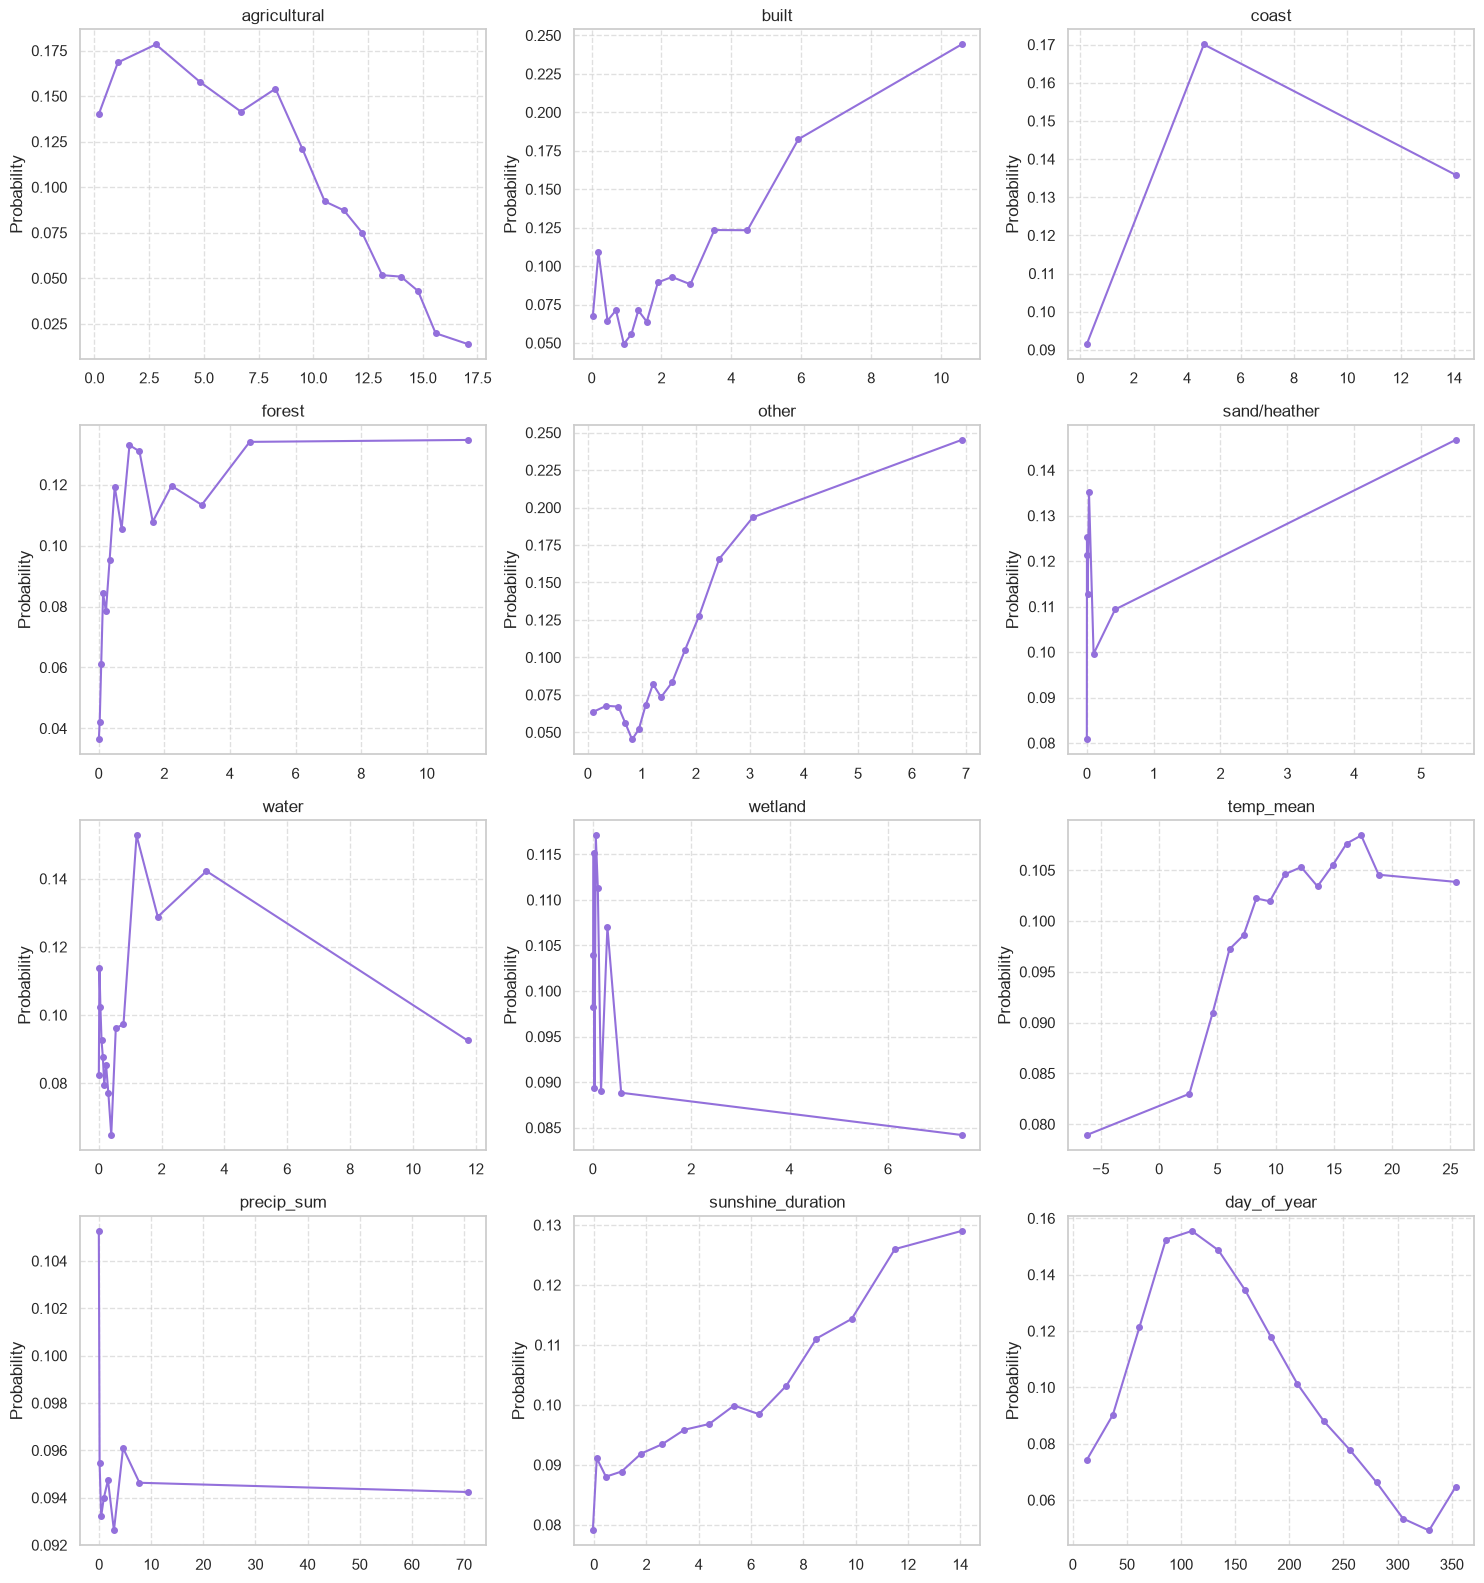

In [16]:
features = [
    "agricultural", "built", "coast", "forest", "other", "sand/heather",
    "water", "wetland", "temp_mean", "precip_sum", "sunshine_duration", "day_of_year"
]

def plot_grid_overview(feature_list, df, bins=15, cols=3):
    # Calculate rows needed
    n_features = len(feature_list)
    rows = (n_features + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()  # Flatten to make it easy to iterate
    
    for i, feature in enumerate(feature_list):
        if feature not in df.columns:
            continue
            
        # Binning logic
        df_plot = df.copy()
        try:
            df_plot['bin'] = pd.qcut(df_plot[feature], q=bins, duplicates='drop')
        except ValueError:
            df_plot['bin'] = pd.cut(df_plot[feature], bins=bins)
        
        grouped = df_plot.groupby('bin', observed=True)['is_spotted'].agg(['mean', 'count'])
        grouped = grouped[grouped['count'] > 50]
        x_values = [interval.mid for interval in grouped.index]
        
        # Plotting onto the specific axis
        axes[i].plot(x_values, grouped['mean'], marker='o', markersize=4, color='mediumpurple')
        axes[i].set_title(feature)
        axes[i].set_ylabel("Probability")
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run it
plot_grid_overview(features, df, cols=3)

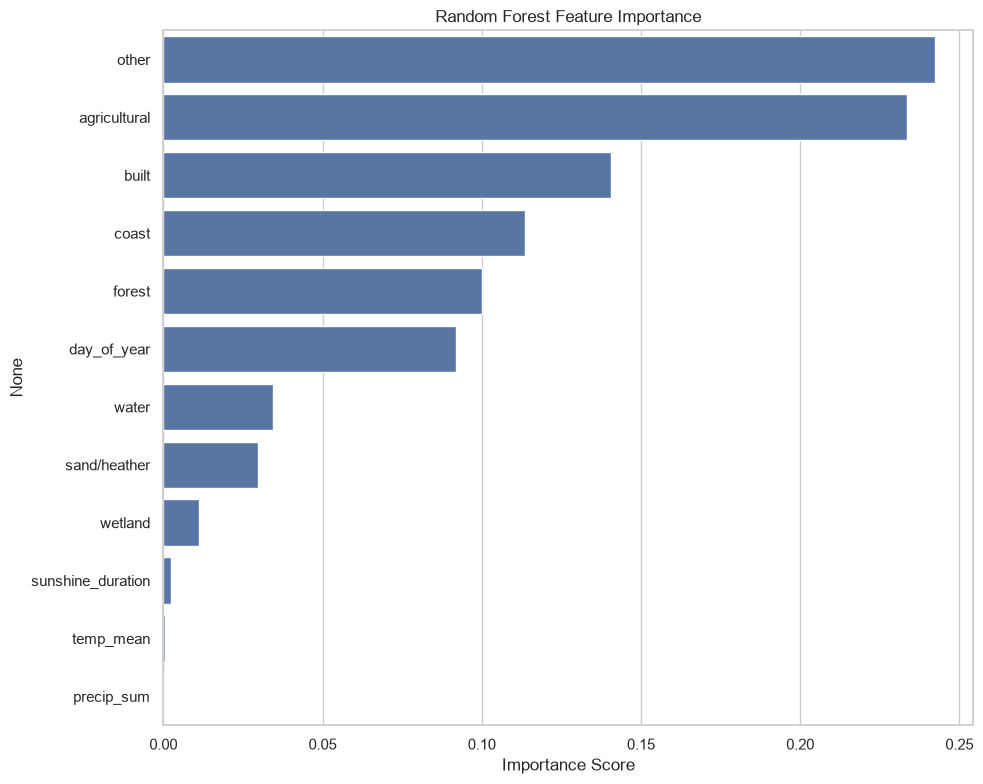

other                0.2423
agricultural         0.2336
built                0.1407
coast                0.1134
forest               0.1002
day_of_year          0.0919
water                0.0343
sand/heather         0.0296
wetland              0.0110
sunshine_duration    0.0025
temp_mean            0.0005
precip_sum           0.0000
dtype: float64


In [17]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
X = df[features]
y = df['is_spotted']

# Train model
rf = RandomForestClassifier(
    n_estimators=300, 
    random_state=42,
    n_jobs=-1,
    max_depth=5
)
rf.fit(X, y)

# Get feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(importances.round(4))

=== Random Forest Feature Importance ===
agricultural         0.2391
other                0.1637
forest               0.1345
built                0.1221
day_of_year          0.0849
coast                0.0808
water                0.0740
sand/heather         0.0458
wetland              0.0449
temp_mean            0.0058
sunshine_duration    0.0034
precip_sum           0.0010
dtype: float64


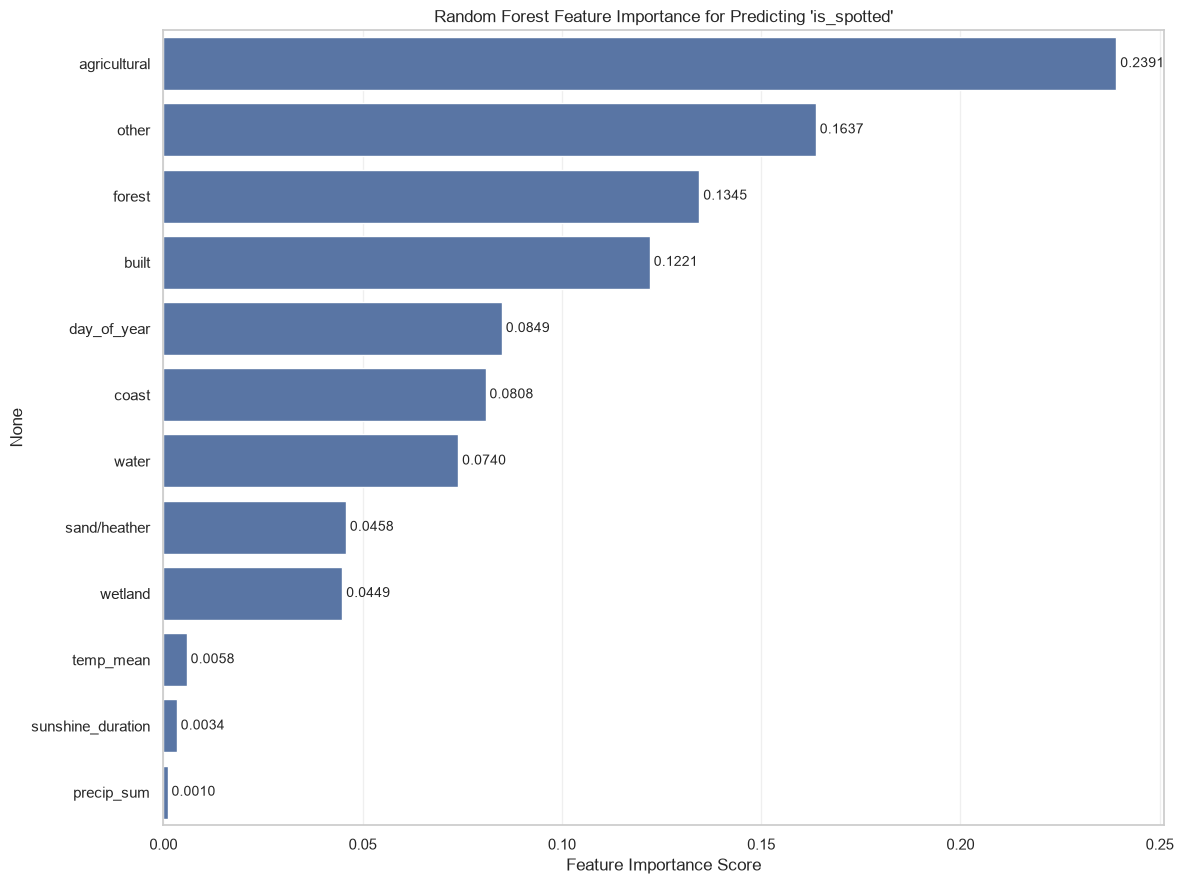

In [18]:
# Install sklearn if not already installed
!pip install scikit-learn -q

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data
features_list = [col for col in features if col != 'is_spotted']
X = df[features_list]
y = df['is_spotted']

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # Important for your imbalance
)

rf.fit(X, y)

# Get importance
importances = pd.Series(rf.feature_importances_, index=features_list)
importances = importances.sort_values(ascending=False)

# Display
print("=== Random Forest Feature Importance ===")
print(importances.round(4))

# Plot
plt.figure(figsize=(12, 9))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importance for Predicting 'is_spotted'")
plt.xlabel("Feature Importance Score")
plt.grid(axis='x', alpha=0.3)

# Add numbers on bars
for i, v in enumerate(importances.values):
    plt.text(v + 0.001, i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Overall Findings of Data Understanding


# 2.2 Data preparation

**Check duplicates, missing values or typos**

In [19]:
df.isnull().sum()

decimalLatitude                0
decimalLongitude               0
eventDate                      0
total_observations             3
speciesgroup_observations      0
Oryctolagus cuniculus          5
agricultural                  30
built                         30
coast                         30
forest                        30
other                         30
sand/heather                  30
water                         30
wetland                       30
main_habitat                  30
nearest_station                0
station_name                   0
temp_mean                    378
precip_sum                   378
sunshine_duration            547
spotted                        0
is_spotted                     0
day_of_year                    0
month                          0
dtype: int64

In [20]:
missing = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(3)
})

missing[missing["Missing values"] > 0]

,Missing values,Percentage (%)
total_observations,3,0.000
Oryctolagus cuniculus,5,0.000
agricultural,30,0.000
built,30,0.000
coast,30,0.000
forest,30,0.000
other,30,0.000
sand/heather,30,0.000
water,30,0.000
wetland,30,0.000


In [21]:
df["total_observations"] = df["total_observations"].fillna(df["total_observations"].median())
df.sort_values(["decimalLatitude", "decimalLongitude"]) \
  .groupby(["decimalLatitude", "decimalLongitude"]) \
  [["temp_mean", "precip_sum", "sunshine_duration"]].ffill()
df = df.dropna()
#check for missing values
df.isnull().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Oryctolagus cuniculus        0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
nearest_station              0
station_name                 0
temp_mean                    0
precip_sum                   0
sunshine_duration            0
spotted                      0
is_spotted                   0
day_of_year                  0
month                        0
dtype: int64

* *We removed all the zero values because when we took a closer look all the values were extreme and not similar at all to the rest of the data*

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


In [24]:
weather_cols = ['temp_mean', 'precip_sum', 'sunshine_duration']
df[weather_cols].describe()

,temp_mean,precip_sum,sunshine_duration
count,1.255816e+07,1.255816e+07,1.255816e+07
mean,1.087058e+01,2.255325e+00,5.071840e+00
std,6.225568e+00,4.692605e+00,4.236424e+00
min,-1.380000e+01,-1.000000e-01,-1.000000e-01
25%,6.400000e+00,0.000000e+00,1.200000e+00
50%,1.080000e+01,1.000000e-01,4.400000e+00
75%,1.580000e+01,2.500000e+00,8.200000e+00
max,3.120000e+01,1.316000e+02,1.570000e+01


In [25]:
df['temp_mean'] = df['temp_mean'] / 10.0
df['precip_sum'] = df['precip_sum'] / 10.0
df['sunshine_duration'] = df['sunshine_duration'] / 10.0

scaler = RobustScaler()
df[weather_cols] = scaler.fit_transform(df[weather_cols])

print("Weather variables scaled with RobustScaler after unit correction.")
print(df[weather_cols].describe())

Weather variables scaled with RobustScaler after unit correction.
          temp_mean    precip_sum  sunshine_duration
count  1.255816e+07  1.255816e+07       1.255816e+07
mean   7.508566e-03  8.621301e-01       9.597715e-02
std    6.622945e-01  1.877042e+00       6.052034e-01
min   -2.617021e+00 -8.000000e-02      -6.428571e-01
25%   -4.680851e-01 -4.000000e-02      -4.571429e-01
50%    0.000000e+00  0.000000e+00       0.000000e+00
75%    5.319149e-01  9.600000e-01       5.428571e-01
max    2.170213e+00  5.260000e+01       1.614286e+00


This code applies standard scaling to the KNMI weather variables (temp_mean, precip_sum, and sunshine_duration).

It transforms these features so they all have a mean of 0 and a standard deviation of 1. This ensures that variables with different units and ranges (°C, mm, hours) become comparable and no single variable dominates the analysis due to its scale.

It was implemented as a preprocessing step to improve data consistency across environmental features and to prepare the dataset for analysis or modelling where feature magnitude can influence results.

# 3. Modeling
**Model Validation Strategy**

In [26]:
target = "is_spotted"

features = [
    "total_observations",
    "speciesgroup_observations",
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_of_year"
]

# Prepare modeling data
df_model = df[features + [target, 'eventDate']].copy()
df_model = df_model.apply(pd.to_numeric, errors='coerce').dropna()

df_model = df_model.sort_values('eventDate').reset_index(drop=True)

# Time-based split
test_ratio = 0.20
split_idx = int(len(df_model) * (1 - test_ratio))

X_train = df_model.iloc[:split_idx][features].copy()
y_train = df_model.iloc[:split_idx][target].copy()
X_test  = df_model.iloc[split_idx:][features].copy()
y_test  = df_model.iloc[split_idx:][target].copy()

# Safe printing
train_pos = float(y_train.mean())
test_pos  = float(y_test.mean())

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Positive rate - Train: {train_pos:.4f} | Test: {test_pos:.4f}")
print(f"Number of features: {len(features)}")

X_train shape: (10046524, 14)
X_test shape : (2511631, 14)
Positive rate - Train: 0.1112 | Test: 0.0536
Number of features: 14


We train test splitted the data into 80% training and 20% testing sets, while maintaining the same proportion of rabbit observations (is_spotted) in both sets.

Model

In [27]:
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.6161641578719167
              precision    recall  f1-score   support

           0       0.98      0.61      0.75   2377043
           1       0.10      0.81      0.18    134588

    accuracy                           0.62   2511631
   macro avg       0.54      0.71      0.47   2511631
weighted avg       0.94      0.62      0.72   2511631

Recall: 0.8087942461437869

Confusion Matrix:
[[1438723  938320]
 [  25734  108854]]


In [28]:
model2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    random_state=42,
    eval_metric='logloss'
)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred = model2.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1690735  686308]
 [  22363  112225]]
              precision    recall  f1-score   support

           0       0.99      0.71      0.83   2377043
           1       0.14      0.83      0.24    134588

    accuracy                           0.72   2511631
   macro avg       0.56      0.77      0.53   2511631
weighted avg       0.94      0.72      0.80   2511631



In [29]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
# 1. Calculate the class imbalance ratio dynamically
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
tscv = TimeSeriesSplit(n_splits=5)
# 2. Instantiate the base model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Define the hyperparameter space to search
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [ratio]
}

# 4. Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 5. Run the hyperparameter search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 6. Extract the best model and parameters
best_model = random_search.best_estimator_
print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}\n")

# 7. Predict and Evaluate using the tuned model
y_pred_tuned = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Starting hyperparameter tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Tuning Complete ---
Best Parameters Found: {'subsample': 0.9, 'scale_pos_weight': 7.990459656454565, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV F1-Score: 0.4349

Confusion Matrix:
[[1739145  637898]
 [  24067  110521]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84   2377043
           1       0.15      0.82      0.25    134588

    accuracy                           0.74   2511631
   macro avg       0.57      0.78      0.55   2511631
weighted avg       0.94      0.74      0.81   2511631



### testing out stuff


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==================== RANDOM FOREST CLASSIFIER ====================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced',      # Important due to imbalance
    bootstrap=True
)

print("Training Random Forest...")
rf.fit(X_train, y_train)

# ==================== PREDICTIONS ====================
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# ==================== EVALUATION ====================
print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importances.head(10).round(4))

Training Random Forest...


KeyboardInterrupt: 

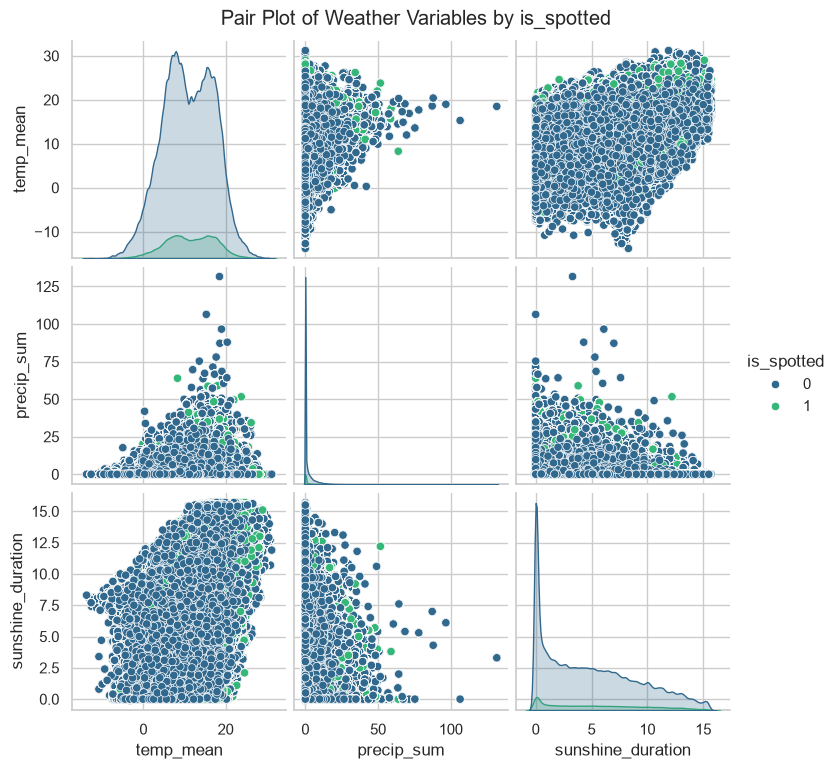

In [ ]:
plot_df = df[['temp_mean', 'precip_sum', 'sunshine_duration', 'is_spotted']]

# Generate the pairplot
sns.pairplot(plot_df, hue='is_spotted', diag_kind='kde', palette='viridis')

plt.suptitle('Pair Plot of Weather Variables by is_spotted', y=1.02)
plt.show()